# Dimer binding energy calculations



In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from ase.io import read

BASE_DIR = Path.cwd()

DIMER_DIR = BASE_DIR / "wB97M" / "tight" / "dimers"
ATOM_DIR = BASE_DIR / "wB97M" / "tight" / "atom"
PLOT_DIR = BASE_DIR / "wB97M" / "tight_corrections"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
print("Dimer directory:", DIMER_DIR.resolve())
print("Atom directory:", ATOM_DIR.resolve())
print("Plot directory:", PLOT_DIR.resolve())

print("Dimer directory exists:", DIMER_DIR.is_dir())
print("Atom directory exists:", ATOM_DIR.is_dir())

Dimer directory: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers
Atom directory: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/atom
Plot directory: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight_corrections
Dimer directory exists: True
Atom directory exists: True


In [12]:
SYSTEMS = {
    "C2H6": {"CH3":2},
    "AlP": {"Al": 1, "P": 1},
    "BN": {"B": 1, "N": 1},
    "BP": {"B": 1, "P": 1},
    "LiCl": {"Li": 1, "Cl": 1},
    "LiF": {"Li": 1, "F": 1},
    "MgO": {"Mg": 1, "O": 1},
    "MgS": {"Mg": 1, "S": 1},
    "NaCl": {"Na": 1, "Cl": 1},
    "NaF": {"Na": 1, "F": 1},
    "Si2H6": {"SiH3":2},
    "SiC": {"Si": 1, "C": 1},
}

In [7]:
def read_final_aims_structure(output_file):
   
    output_file = Path(output_file)

    if not output_file.is_file():
        raise FileNotFoundError(f"File not found: {output_file}")

    images = read(
        output_file,
        format="aims-output",
        index=":",
    )

    if not images:
        raise ValueError(
            f"No readable structures found in {output_file}"
        )

    # Work backward in case the final incomplete image lacks energy data.
    for atoms in reversed(images):
        try:
            atoms.get_potential_energy()
            return atoms
        except Exception:
            continue

    raise ValueError(
        f"No structure with an energy was found in {output_file}"
    )


def read_aims_energy(output_file):
    atoms = read_final_aims_structure(output_file)
    return atoms.get_potential_energy()

In [9]:
def get_dimer_distance(atoms, system_name):
    """
    Return the relevant interatomic distance in angstroms.
    """
    symbols = atoms.get_chemical_symbols()

    if system_name == "C2H6":
        central_indices = [
            index
            for index, symbol in enumerate(symbols)
            if symbol == "C"
        ]

    elif system_name == "Si2H6":
        central_indices = [
            index
            for index, symbol in enumerate(symbols)
            if symbol == "Si"
        ]

    else:
        if len(atoms) != 2:
            raise ValueError(
                f"{system_name} contains {len(atoms)} atoms; "
                "expected a diatomic structure."
            )CoCo

        central_indices = [0, 1]

    if len(central_indices) != 2:
        raise ValueError(
            f"Could not identify exactly two central atoms for "
            f"{system_name}. Found indices: {central_indices}"
        )

    return atoms.get_distance(
        central_indices[0],
        central_indices[1],
        mic=False,
    )

In [16]:

def find_reference_output(reference_name):
    
    possible_files = [
        ATOM_DIR / f"{reference_name}_aims.out",
    ]

    for output_file in possible_files:
        if output_file.is_file():
            return output_file

    matching_files = sorted(
        path
        for path in ATOM_DIR.glob("*")
        if path.is_file()
        and reference_name.lower() in path.stem.lower()
        and path.suffix == ".out"
    )

    if len(matching_files) == 1:
        return matching_files[0]

    if len(matching_files) > 1:
        raise ValueError(
            f"Multiple possible output files found for {reference_name}: "
            + ", ".join(str(path) for path in matching_files)
        )

    raise FileNotFoundError(
        f"No output file found for {reference_name} directly under "
        f"{ATOM_DIR}"
    )

In [17]:
reference_names = sorted(
    {
        reference_name
        for reference_composition in SYSTEMS.values()
        for reference_name in reference_composition
    }
)

reference_energies = {}

for reference_name in reference_names:
    try:
        output_file = find_reference_output(reference_name)
        energy = read_aims_energy(output_file)

        reference_energies[reference_name] = energy

        print(
            f"{reference_name:>4}: "
            f"{energy: .10f} eV "
            f"from {output_file.name}"
        )

    except Exception as error:
        print(
            f"Could not read reference {reference_name}: "
            f"{error}"
        )

  Al: -6615.2804414218 eV from Al_aims.out
   B: -671.6701915131 eV from B_aims.out
   C: -1031.2740628923 eV from C_aims.out
 CH3: -1085.2915834085 eV from CH3_aims.out
  Cl: -12584.0095233628 eV from Cl_aims.out
   F: -2719.2576333532 eV from F_aims.out
  Li: -203.6967442971 eV from Li_aims.out
  Mg: -5458.9344969532 eV from Mg_aims.out
   N: -1487.7290959488 eV from N_aims.out
  Na: -4425.9075720674 eV from Na_aims.out
   O: -2046.3213115353 eV from O_aims.out
   P: -9323.1026621660 eV from P_aims.out
   S: -10881.6854392044 eV from S_aims.out
  Si: -7901.7868458456 eV from Si_aims.out
SiH3: -7952.2930801707 eV from SiH3_aims.out


Plots will be saved in: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results
  C2H6 | C2H6_scale_0.800_aims.out      | R = 1.2320 Å | Ebind = 2.088286 eV
  C2H6 | C2H6_scale_0.850_aims.out      | R = 1.3090 Å | Ebind = 3.195592 eV
  C2H6 | C2H6_scale_0.900_aims.out      | R = 1.3860 Å | Ebind = 3.819394 eV
  C2H6 | C2H6_scale_0.950_aims.out      | R = 1.4630 Å | Ebind = 4.107756 eV
  C2H6 | C2H6_scale_1.000_aims.out      | R = 1.5400 Å | Ebind = 4.164646 eV
  C2H6 | C2H6_scale_1.050_aims.out      | R = 1.6170 Å | Ebind = 4.063418 eV
  C2H6 | C2H6_scale_1.100_aims.out      | R = 1.6940 Å | Ebind = 3.855996 eV
  C2H6 | C2H6_scale_1.200_aims.out      | R = 1.8480 Å | Ebind = 3.259428 eV
  C2H6 | C2H6_scale_1.300_aims.out      | R = 2.0020 Å | Ebind = 2.559702 eV
  C2H6 | C2H6_scale_1.500_aims.out      | R = 2.3100 Å | Ebind = 1.174801 eV
  C2H6 | C2H6_scale_1.750_aims.out      | R = 2.6950 Å | Ebind = -0.262350 eV


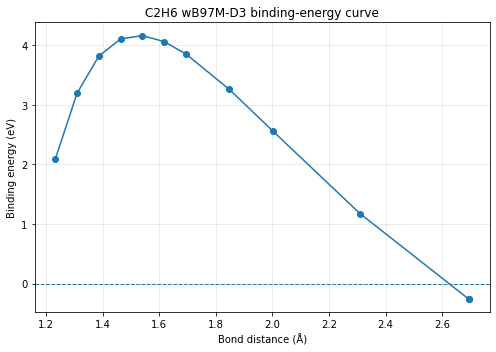

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/C2H6_binding_energy_curve.png
   AlP | AlP_scale_0.800_aims.out       | R = 1.9200 Å | Ebind = 1.228242 eV
   AlP | AlP_scale_0.850_aims.out       | R = 2.0400 Å | Ebind = 1.494007 eV
   AlP | AlP_scale_0.900_aims.out       | R = 2.1600 Å | Ebind = 1.472061 eV
   AlP | AlP_scale_0.950_aims.out       | R = 2.2800 Å | Ebind = 1.288581 eV
   AlP | AlP_scale_1.000_aims.out       | R = 2.4000 Å | Ebind = 1.024013 eV
   AlP | AlP_scale_1.050_aims.out       | R = 2.5200 Å | Ebind = 0.727163 eV
   AlP | AlP_scale_1.100_aims.out       | R = 2.6400 Å | Ebind = 0.425584 eV
   AlP | AlP_scale_1.200_aims.out       | R = 2.8800 Å | Ebind = -0.143693 eV
   AlP | AlP_scale_1.300_aims.out       | R = 3.1200 Å | Ebind = -0.643460 eV
   AlP | AlP_scale_1.500_aims.out       | R = 3.6000 Å | Ebind = -3.123891 eV
   AlP | AlP_scale_1.750_aims.out       | R = 4.2000 Å | Ebind = -3.989242 eV


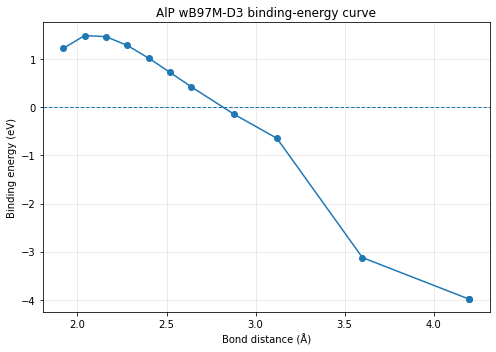

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/AlP_binding_energy_curve.png
    BN | BN_scale_0.800_aims.out        | R = 1.1520 Å | Ebind = 3.286315 eV
    BN | BN_scale_0.850_aims.out        | R = 1.2240 Å | Ebind = 3.753374 eV
    BN | BN_scale_0.900_aims.out        | R = 1.2960 Å | Ebind = 3.753795 eV
    BN | BN_scale_0.950_aims.out        | R = 1.3680 Å | Ebind = 3.458819 eV
    BN | BN_scale_1.000_aims.out        | R = 1.4400 Å | Ebind = 2.988786 eV
    BN | BN_scale_1.050_aims.out        | R = 1.5120 Å | Ebind = 2.427939 eV
    BN | BN_scale_1.100_aims.out        | R = 1.5840 Å | Ebind = 1.834228 eV
    BN | BN_scale_1.200_aims.out        | R = 1.7280 Å | Ebind = 0.686884 eV
    BN | BN_scale_1.300_aims.out        | R = 1.8720 Å | Ebind = -0.301452 eV
    BN | BN_scale_1.500_aims.out        | R = 2.1600 Å | Ebind = -1.769669 eV
    BN | BN_scale_1.750_aims.out        | R = 2.5200 Å | Ebind = -2.972141 eV


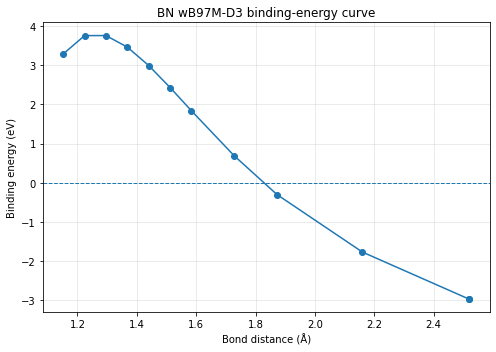

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/BN_binding_energy_curve.png
    BP | BP_scale_0.800_aims.out        | R = 1.4400 Å | Ebind = 1.643352 eV
    BP | BP_scale_0.850_aims.out        | R = 1.5300 Å | Ebind = 2.464747 eV
    BP | BP_scale_0.900_aims.out        | R = 1.6200 Å | Ebind = 2.760472 eV
    BP | BP_scale_0.950_aims.out        | R = 1.7100 Å | Ebind = 2.714487 eV
    BP | BP_scale_1.000_aims.out        | R = 1.8000 Å | Ebind = 2.457772 eV
    BP | BP_scale_1.050_aims.out        | R = 1.8900 Å | Ebind = 2.081928 eV
    BP | BP_scale_1.100_aims.out        | R = 1.9800 Å | Ebind = 1.649254 eV
    BP | BP_scale_1.200_aims.out        | R = 2.1600 Å | Ebind = 0.759296 eV
    BP | BP_scale_1.300_aims.out        | R = 2.3400 Å | Ebind = -0.049424 eV
    BP | BP_scale_1.500_aims.out        | R = 2.7000 Å | Ebind = -2.748963 eV
    BP | BP_scale_1.750_aims.out        | R = 3.1500 Å | Ebind = -3.815294 eV


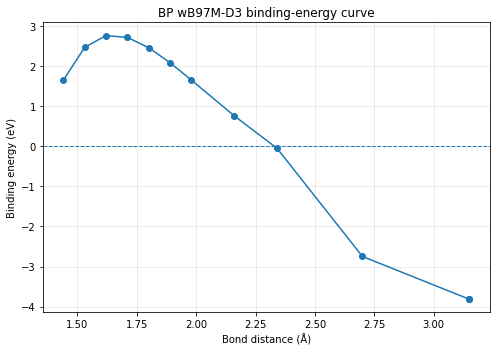

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/BP_binding_energy_curve.png
  LiCl | LiCl_scale_0.800_aims.out      | R = 1.6160 Å | Ebind = 3.616995 eV
  LiCl | LiCl_scale_0.850_aims.out      | R = 1.7170 Å | Ebind = 4.309635 eV
  LiCl | LiCl_scale_0.900_aims.out      | R = 1.8180 Å | Ebind = 4.706383 eV
  LiCl | LiCl_scale_0.950_aims.out      | R = 1.9190 Å | Ebind = 4.900766 eV
  LiCl | LiCl_scale_1.000_aims.out      | R = 2.0200 Å | Ebind = 4.957398 eV
  LiCl | LiCl_scale_1.050_aims.out      | R = 2.1210 Å | Ebind = 4.921197 eV
  LiCl | LiCl_scale_1.100_aims.out      | R = 2.2220 Å | Ebind = 4.823435 eV
  LiCl | LiCl_scale_1.200_aims.out      | R = 2.4240 Å | Ebind = 4.523638 eV
  LiCl | LiCl_scale_1.300_aims.out      | R = 2.6260 Å | Ebind = 4.163636 eV
  LiCl | LiCl_scale_1.500_aims.out      | R = 3.0300 Å | Ebind = 3.435538 eV
  LiCl | LiCl_scale_1.750_aims.out      | R = 3.5350 Å | Ebind = 2.646600 eV


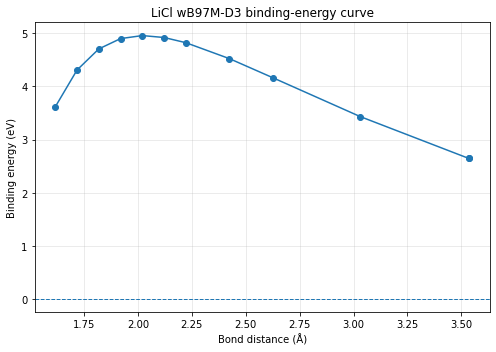

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/LiCl_binding_energy_curve.png
   LiF | LiF_scale_0.800_aims.out       | R = 1.2480 Å | Ebind = 4.546534 eV
   LiF | LiF_scale_0.850_aims.out       | R = 1.3260 Å | Ebind = 5.294574 eV
   LiF | LiF_scale_0.900_aims.out       | R = 1.4040 Å | Ebind = 5.725942 eV
   LiF | LiF_scale_0.950_aims.out       | R = 1.4820 Å | Ebind = 5.941168 eV
   LiF | LiF_scale_1.000_aims.out       | R = 1.5600 Å | Ebind = 6.009195 eV
   LiF | LiF_scale_1.050_aims.out       | R = 1.6380 Å | Ebind = 5.977540 eV
   LiF | LiF_scale_1.100_aims.out       | R = 1.7160 Å | Ebind = 5.879580 eV
   LiF | LiF_scale_1.200_aims.out       | R = 1.8720 Å | Ebind = 5.569746 eV
   LiF | LiF_scale_1.300_aims.out       | R = 2.0280 Å | Ebind = 5.191872 eV
   LiF | LiF_scale_1.500_aims.out       | R = 2.3400 Å | Ebind = 4.418644 eV
   LiF | LiF_scale_1.750_aims.out       | R = 2.7300 Å | Ebind = 3.565858 eV


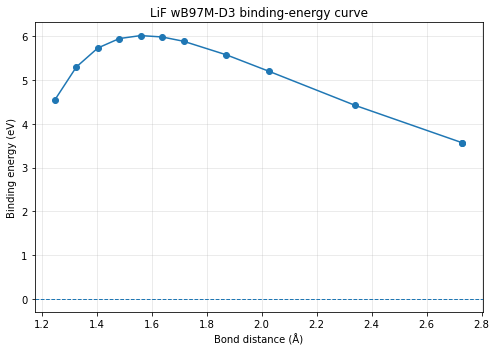

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/LiF_binding_energy_curve.png
   MgO | MgO_scale_0.800_aims.out       | R = 1.4000 Å | Ebind = -0.482834 eV
   MgO | MgO_scale_0.850_aims.out       | R = 1.4875 Å | Ebind = 0.892430 eV
   MgO | MgO_scale_0.900_aims.out       | R = 1.5750 Å | Ebind = 1.637940 eV
   MgO | MgO_scale_0.950_aims.out       | R = 1.6625 Å | Ebind = 1.963416 eV
   MgO | MgO_scale_1.000_aims.out       | R = 1.7500 Å | Ebind = 2.015783 eV
   MgO | MgO_scale_1.050_aims.out       | R = 1.8375 Å | Ebind = 1.896255 eV
   MgO | MgO_scale_1.100_aims.out       | R = 1.9250 Å | Ebind = 1.673801 eV
   MgO | MgO_scale_1.200_aims.out       | R = 2.1000 Å | Ebind = 1.091133 eV
   MgO | MgO_scale_1.300_aims.out       | R = 2.2750 Å | Ebind = 0.481284 eV
   MgO | MgO_scale_1.500_aims.out       | R = 2.6250 Å | Ebind = -0.546552 eV
   MgO | MgO_scale_1.750_aims.out       | R = 3.0625 Å | Ebind = -1.403835 eV


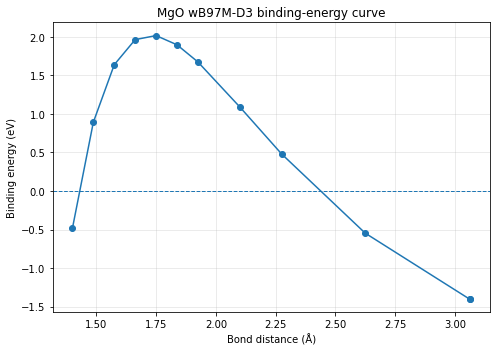

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/MgO_binding_energy_curve.png
   MgS | MgS_scale_0.800_aims.out       | R = 1.7360 Å | Ebind = -0.169254 eV
   MgS | MgS_scale_0.850_aims.out       | R = 1.8445 Å | Ebind = 1.017754 eV
   MgS | MgS_scale_0.900_aims.out       | R = 1.9530 Å | Ebind = 1.658824 eV
   MgS | MgS_scale_0.950_aims.out       | R = 2.0615 Å | Ebind = 1.930402 eV
   MgS | MgS_scale_1.000_aims.out       | R = 2.1700 Å | Ebind = 1.960214 eV
   MgS | MgS_scale_1.050_aims.out       | R = 2.2785 Å | Ebind = 1.838521 eV
   MgS | MgS_scale_1.100_aims.out       | R = 2.3870 Å | Ebind = 1.627967 eV
   MgS | MgS_scale_1.200_aims.out       | R = 2.6040 Å | Ebind = 1.096582 eV
   MgS | MgS_scale_1.300_aims.out       | R = 2.8210 Å | Ebind = 0.559191 eV
   MgS | MgS_scale_1.500_aims.out       | R = 3.2550 Å | Ebind = -0.296574 eV
   MgS | MgS_scale_1.750_aims.out       | R = 3.7975 Å | Ebind = -0.931259 eV


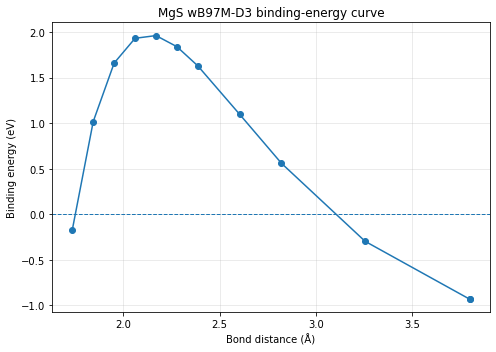

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/MgS_binding_energy_curve.png
  NaCl | NaCl_scale_0.800_aims.out      | R = 1.8880 Å | Ebind = 2.650078 eV
  NaCl | NaCl_scale_0.850_aims.out      | R = 2.0060 Å | Ebind = 3.459658 eV
  NaCl | NaCl_scale_0.900_aims.out      | R = 2.1240 Å | Ebind = 3.909794 eV
  NaCl | NaCl_scale_0.950_aims.out      | R = 2.2420 Å | Ebind = 4.124165 eV
  NaCl | NaCl_scale_1.000_aims.out      | R = 2.3600 Å | Ebind = 4.185717 eV
  NaCl | NaCl_scale_1.050_aims.out      | R = 2.4780 Å | Ebind = 4.149546 eV
  NaCl | NaCl_scale_1.100_aims.out      | R = 2.5960 Å | Ebind = 4.051933 eV
  NaCl | NaCl_scale_1.200_aims.out      | R = 2.8320 Å | Ebind = 3.759794 eV
  NaCl | NaCl_scale_1.300_aims.out      | R = 3.0680 Å | Ebind = 3.418756 eV
  NaCl | NaCl_scale_1.500_aims.out      | R = 3.5400 Å | Ebind = 2.752671 eV
  NaCl | NaCl_scale_1.750_aims.out      | R = 4.1300 Å | Ebind = 2.061579 eV


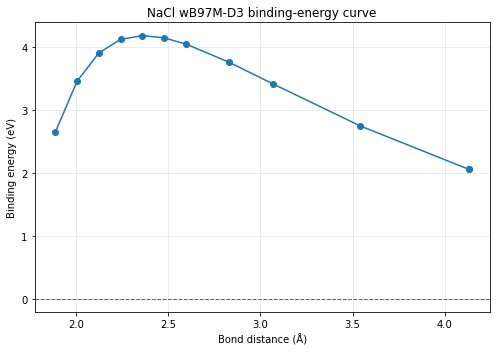

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/NaCl_binding_energy_curve.png
   NaF | NaF_scale_0.800_aims.out       | R = 1.5520 Å | Ebind = 3.249584 eV
   NaF | NaF_scale_0.850_aims.out       | R = 1.6490 Å | Ebind = 4.114998 eV
   NaF | NaF_scale_0.900_aims.out       | R = 1.7460 Å | Ebind = 4.584959 eV
   NaF | NaF_scale_0.950_aims.out       | R = 1.8430 Å | Ebind = 4.802256 eV
   NaF | NaF_scale_1.000_aims.out       | R = 1.9400 Å | Ebind = 4.859159 eV
   NaF | NaF_scale_1.050_aims.out       | R = 2.0370 Å | Ebind = 4.815336 eV
   NaF | NaF_scale_1.100_aims.out       | R = 2.1340 Å | Ebind = 4.709228 eV
   NaF | NaF_scale_1.200_aims.out       | R = 2.3280 Å | Ebind = 4.400759 eV
   NaF | NaF_scale_1.300_aims.out       | R = 2.5220 Å | Ebind = 4.045054 eV
   NaF | NaF_scale_1.500_aims.out       | R = 2.9100 Å | Ebind = 3.352125 eV
   NaF | NaF_scale_1.750_aims.out       | R = 3.3950 Å | Ebind = 2.626350 eV


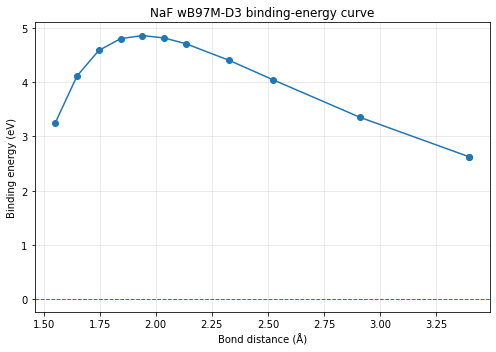

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/NaF_binding_energy_curve.png
 Si2H6 | Si2H6_scale_0.800_aims.out     | R = 1.8640 Å | Ebind = 1.167618 eV
 Si2H6 | Si2H6_scale_0.850_aims.out     | R = 1.9805 Å | Ebind = 2.336235 eV
 Si2H6 | Si2H6_scale_0.900_aims.out     | R = 2.0970 Å | Ebind = 2.998413 eV
 Si2H6 | Si2H6_scale_0.950_aims.out     | R = 2.2135 Å | Ebind = 3.318404 eV
 Si2H6 | Si2H6_scale_1.000_aims.out     | R = 2.3300 Å | Ebind = 3.408713 eV
 Si2H6 | Si2H6_scale_1.050_aims.out     | R = 2.4465 Å | Ebind = 3.346525 eV
 Si2H6 | Si2H6_scale_1.100_aims.out     | R = 2.5630 Å | Ebind = 3.184925 eV
 Si2H6 | Si2H6_scale_1.200_aims.out     | R = 2.7960 Å | Ebind = 2.698461 eV
 Si2H6 | Si2H6_scale_1.300_aims.out     | R = 3.0290 Å | Ebind = 2.125545 eV
 Si2H6 | Si2H6_scale_1.500_aims.out     | R = 3.4950 Å | Ebind = 1.008693 eV
 Si2H6 | Si2H6_scale_1.750_aims.out     | R = 4.0775 Å | Ebind = -0.109843 eV


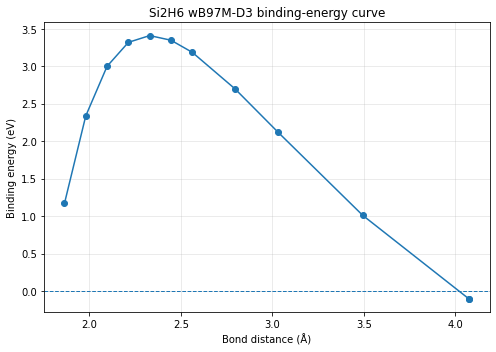

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/Si2H6_binding_energy_curve.png
   SiC | SiC_scale_0.800_aims.out       | R = 1.3760 Å | Ebind = 1.141362 eV
   SiC | SiC_scale_0.850_aims.out       | R = 1.4620 Å | Ebind = 2.366779 eV
   SiC | SiC_scale_0.900_aims.out       | R = 1.5480 Å | Ebind = 2.960180 eV
   SiC | SiC_scale_0.950_aims.out       | R = 1.6340 Å | Ebind = 3.127146 eV
   SiC | SiC_scale_1.000_aims.out       | R = 1.7200 Å | Ebind = 3.014213 eV
   SiC | SiC_scale_1.050_aims.out       | R = 1.8060 Å | Ebind = 2.724966 eV
   SiC | SiC_scale_1.100_aims.out       | R = 1.8920 Å | Ebind = 2.331504 eV
   SiC | SiC_scale_1.200_aims.out       | R = 2.0640 Å | Ebind = -0.240599 eV
   SiC | SiC_scale_1.300_aims.out       | R = 2.2360 Å | Ebind = -0.861245 eV
   SiC | SiC_scale_1.500_aims.out       | R = 2.5800 Å | Ebind = -2.244094 eV
   SiC | SiC_scale_1.750_aims.out       | R = 3.0100 Å | Ebind = -3.717017 eV


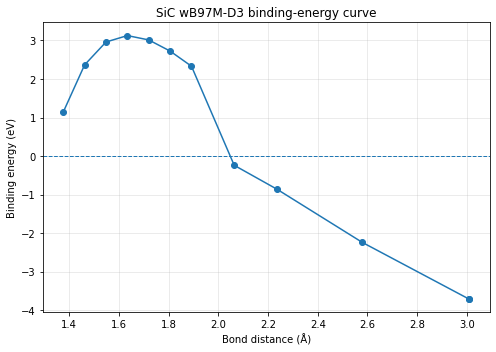

Saved plot: /mnt/ceph/users/cwoodson/dft_calc/analysis/wB97M/tight/dimers/results/SiC_binding_energy_curve.png


In [27]:
RESULTS_DIR = DIMER_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved in: {RESULTS_DIR.resolve()}")


for system_name, reference_composition in SYSTEMS.items():

    missing_references = [
        reference_name
        for reference_name in reference_composition
        if reference_name not in reference_energies
    ]

    if missing_references:
        print(
            f"Skipping {system_name}: missing reference energies for "
            f"{', '.join(missing_references)}"
        )
        continue

    separated_reference_energy = sum(
        count * reference_energies[reference_name]
        for reference_name, count in reference_composition.items()
    )

    # Find output files for this system directly inside DIMER_DIR.
    output_files = sorted(
        path
        for path in DIMER_DIR.glob(f"{system_name}*.out")
        if path.is_file()
    )

    if not output_files:
        print(
            f"Skipping {system_name}: no matching .out files found in "
            f"{DIMER_DIR}"
        )
        continue

    distances = []
    binding_energies = []

    for output_file in output_files:
        try:
            atoms = read_final_aims_structure(output_file)

            dimer_energy = atoms.get_potential_energy()

            distance = get_dimer_distance(
                atoms,
                system_name,
            )

            binding_energy = (
                -(dimer_energy
                - separated_reference_energy)
            )

            distances.append(distance)
            binding_energies.append(binding_energy)

            print(
                f"{system_name:>6} | "
                f"{output_file.name:<30} | "
                f"R = {distance:.4f} Å | "
                f"Ebind = {binding_energy:.6f} eV"
            )

        except Exception as error:
            print(
                f"Skipping {output_file.name}: {error}"
            )

    if not distances:
        print(
            f"Skipping {system_name}: "
            "none of the matching output files could be read"
        )
        continue

    # Sort points by measured bond distance.
    sorted_points = sorted(
        zip(distances, binding_energies)
    )

    distances = [
        point[0]
        for point in sorted_points
    ]

    binding_energies = [
        point[1]
        for point in sorted_points
    ]

    plt.figure(figsize=(7, 5))

    plt.plot(
        distances,
        binding_energies,
        marker="o",
    )

    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel("Bond distance (Å)")
    plt.ylabel("Binding energy (eV)")
    plt.title(
        f"{system_name} wB97M-D3 binding-energy curve"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plot_file = (
        RESULTS_DIR
        / f"{system_name}_binding_energy_curve.png"
    )

    plt.savefig(
        plot_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    print(f"Saved plot: {plot_file}")